# Import

In [58]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import OllamaLLM
import networkx as nx
from langchain_openai import OpenAI, ChatOpenAI
import tomllib
import json

In [24]:
graph = nx.Graph()

In [25]:
with open("..\secrets.toml", "rb") as f:
    secrets = tomllib.load(f)

In [31]:
# llm = OllamaLLM(model="llama3.2:latest", temperature=0)
# llm_json = OllamaLLM(model="llama3.2:latest", temperature=0, response_format="json")
# llm = OllamaLLM(model="gpt-oss:20b", temperature=0)
# llm_json = OllamaLLM(model="gpt-oss:20b", temperature=0, response_format="json")

llm = ChatOpenAI(model_name="gpt-5-nano", api_key=secrets["api_keys"]["openai"])

# AIML Model Families

In [37]:
prompt = """I am trying to create a graph of AIML models and their explainability methods.
First, I need a list of AIML model families such as 'Classification and Regression Trees', 'Regression','Neural Networks', 'Support Vector Machines', and 'Time-Series', etc.
List out the families of AIML models and they should be exhaustive.
The model families listed should be specific such that algorithms belonging to one particular model family do not fit into another model family.
(e.g., Decision Trees and Random Forests belong to the same family 'Classification and Regression Trees' and not two different families, so they should not be listed seperately).
Also provide a sinlge line description of each model family.
provide the results as a list of json objects with 'name' and 'description' as keys. Do not number them.
Return only the list of json objects and no other text. Do not use any special characters. Use pure json format directly parsable by python json library.
"""
response = llm.invoke(prompt)

In [59]:
model_families = json.loads(response.content)

Here is a response from ChatGPT ([link](https://chatgpt.com/c/68cc39b3-3d4c-8333-ae14-bef0f90e22bf)). We will use these as the AIML Model Family nodes.

In [60]:
import json
[i['name'] for i in model_families]

['Regression',
 'Classification and Regression Trees',
 'Neural Networks',
 'Support Vector Machines',
 'Time-Series',
 'Bayesian Methods',
 'Clustering',
 'Dimensionality Reduction',
 'Reinforcement Learning',
 'Probabilistic Graphical Models',
 'Evolutionary Computation']

In [ ]:
# model_families = ["Linear Models", "Generalized Linear Models", "Classification and Regression Trees", "Rule-Based Models", "Support Vector Machines", "Instance-Based Models", "Ensemble Methods", "Feedforward Neural Networks", "Convolutional Neural Networks", "Recurrent Neural Networks", "Transformer-Based Models", "Probabilistic Graphical Models", "Bayesian Methods", "Evolutionary Algorithms", "Clustering Models", "Dimensionality Reduction Models", "Anomaly Detection Models", "Time-Series Models", "Reinforcement Learning Models"]
# model_families_desc = {
# "Linear Models": "Models that assume a linear relationship between input features and output (e.g., Linear Regression, Perceptron).",
# "Generalized Linear Models": "Extension of linear models allowing non-normal response distributions using link functions (e.g., Logistic Regression, Poisson Regression).",
# "Classification and Regression Trees": "Single decision tree models for classification and regression tasks.",
# "Rule-Based Models": "Models that use human-readable rules for prediction (e.g., RIPPER, OneR, decision lists).",
# "Support Vector Machines": "Models that find optimal separating hyperplanes using kernels for classification or regression.",
# "Instance-Based Models": "Models that rely on similarity to training examples (e.g., k-Nearest Neighbors, Locally Weighted Regression).",
# "Ensemble Methods": "Models that combine multiple base learners to improve performance (e.g., Bagging, Boosting, Stacking).",
# "Feedforward Neural Networks": "Basic multi-layer perceptrons with fully connected layers, mapping input to output directly.",
# "Convolutional Neural Networks": "Neural networks specialized for grid-structured data like images, using convolutional layers.",
# "Recurrent Neural Networks": "Neural networks with feedback connections designed for sequential data (e.g., LSTM, GRU).",
# "Transformer-Based Models": "Attention-based neural networks, including large language models (e.g., GPT, BERT, T5).",
# "Probabilistic Graphical Models": "Graph-based models capturing dependencies among variables (e.g., Bayesian Networks, Markov Random Fields).",
# "Bayesian Methods": "Models using Bayes’ theorem to update beliefs with evidence (e.g., Naive Bayes, Bayesian inference).",
# "Evolutionary Algorithms": "Optimization algorithms inspired by natural selection (e.g., Genetic Algorithms, Genetic Programming).",
# "Clustering Models": "Unsupervised models grouping data points based on similarity (e.g., K-Means, DBSCAN, Hierarchical Clustering).",
# "Dimensionality Reduction Models": "Models that reduce feature space while preserving structure (e.g., PCA, t-SNE, Autoencoders).",
# "Anomaly Detection Models": "Models identifying unusual or rare patterns that deviate from expected behavior.",
# "Time-Series Models": "Models capturing temporal dependencies and trends (e.g., ARIMA, Prophet, RNN-based forecasting).",
# "Reinforcement Learning Models": "Models that learn policies through interaction with an environment using rewards and penalties."
# }

In [46]:
graph.add_nodes_from([(i['name'], {'description': i['description']}) for i in json.loads(response.content)], type='AIML Model Family')

In [47]:
graph.nodes(data=True)

NodeDataView({'Regression': {'description': 'Models for predicting continuous numeric targets using linear, polynomial, ridge, lasso, elastic-net, and related regression techniques.', 'type': 'AIML Model Family'}, 'Classification and Regression Trees': {'description': 'Tree-based models including decision trees, random forests, gradient boosting and related ensembles for classification and/or regression.', 'type': 'AIML Model Family'}, 'Neural Networks': {'description': 'Models built from interconnected artificial neurons spanning feedforward, recurrent, convolutional, and transformer architectures.', 'type': 'AIML Model Family'}, 'Support Vector Machines': {'description': 'Margin-based classifiers and regressors that use kernel functions to handle linear and non-linear decision boundaries.', 'type': 'AIML Model Family'}, 'Time-Series': {'description': 'Models tailored for forecasting sequential data such as ARIMA, SARIMA, exponential smoothing, Holt-Winters, and Prophet style methods.

In [ ]:
# import pickle
# with open('..\graph.pkl', 'wb') as file:
#     pickle.dump(graph, file)


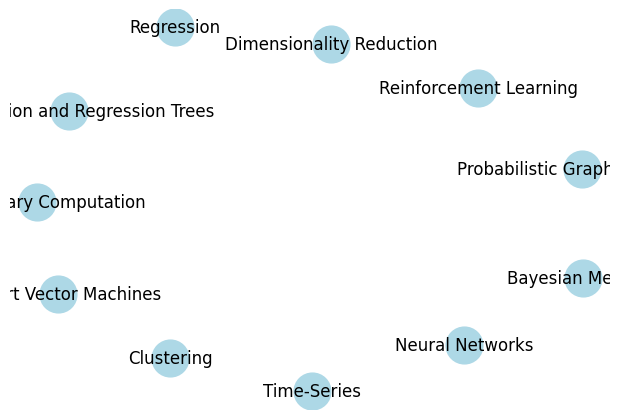

In [48]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 4))
# nx.draw(graph, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700)
# plt.show()

# AIML Model Algorithms

## Getting Algorithms

In [62]:
models_prompt = PromptTemplate.from_template("""List 5-10 popular algorithms belonging to the AIML model family '{model_family}'.
                                             Here is a description of the type of models that belong to this family: {model_family_desc}.
                                             Also provide a sinlge line description of each model family.
                                             Provide the results as a list of json objects with 'name' and 'description' as keys. Do not number them.
                                             Return only the list of json objects and no other text. Do not use any special characters. Use pure json format directly parsable by python json library.""")

In [66]:
model_chain = models_prompt | llm | StrOutputParser()
nodes = []
edges = []
for model_fam in model_families:
    response = model_chain.invoke({'model_family': model_fam['name'], 'model_family_desc': model_fam['description']})
    # print(response)
    models = json.loads(response)
    for model in models:
        nodes.append((model['name'], {'description': model['description']}))
        edges.append((model_fam['name'], model['name'], {'relationship': 'has_model'}))

In [67]:
print(nodes)
print(edges)

[('Linear Regression', {'description': 'Predicts a numeric target as a linear combination of input features.'}), ('Polynomial Regression', {'description': 'Extends linear regression by fitting a polynomial relationship to capture nonlinear patterns.'}), ('Ridge Regression', {'description': 'Linear regression with L2 regularization to prevent overfitting.'}), ('Lasso Regression', {'description': 'Linear regression with L1 regularization for feature selection.'}), ('Elastic Net Regression', {'description': 'Combines L1 and L2 penalties to balance feature selection and regularization.'}), ('Support Vector Regression', {'description': 'Uses kernel-based methods to fit a regression function with robust handling of outliers.'}), ('Bayesian Linear Regression', {'description': 'Treats regression coefficients as probabilistic, providing uncertainty estimates.'}), ('Huber Regression', {'description': 'Robust regression that uses a loss function less sensitive to outliers than ordinary least squa

In [68]:
graph.add_nodes_from(nodes, type='AIML Model Algorithm')
graph.add_edges_from(edges)

In [ ]:
# import pickle
# with open('..\graph2.pkl', 'wb') as file:
#     pickle.dump(graph, file)

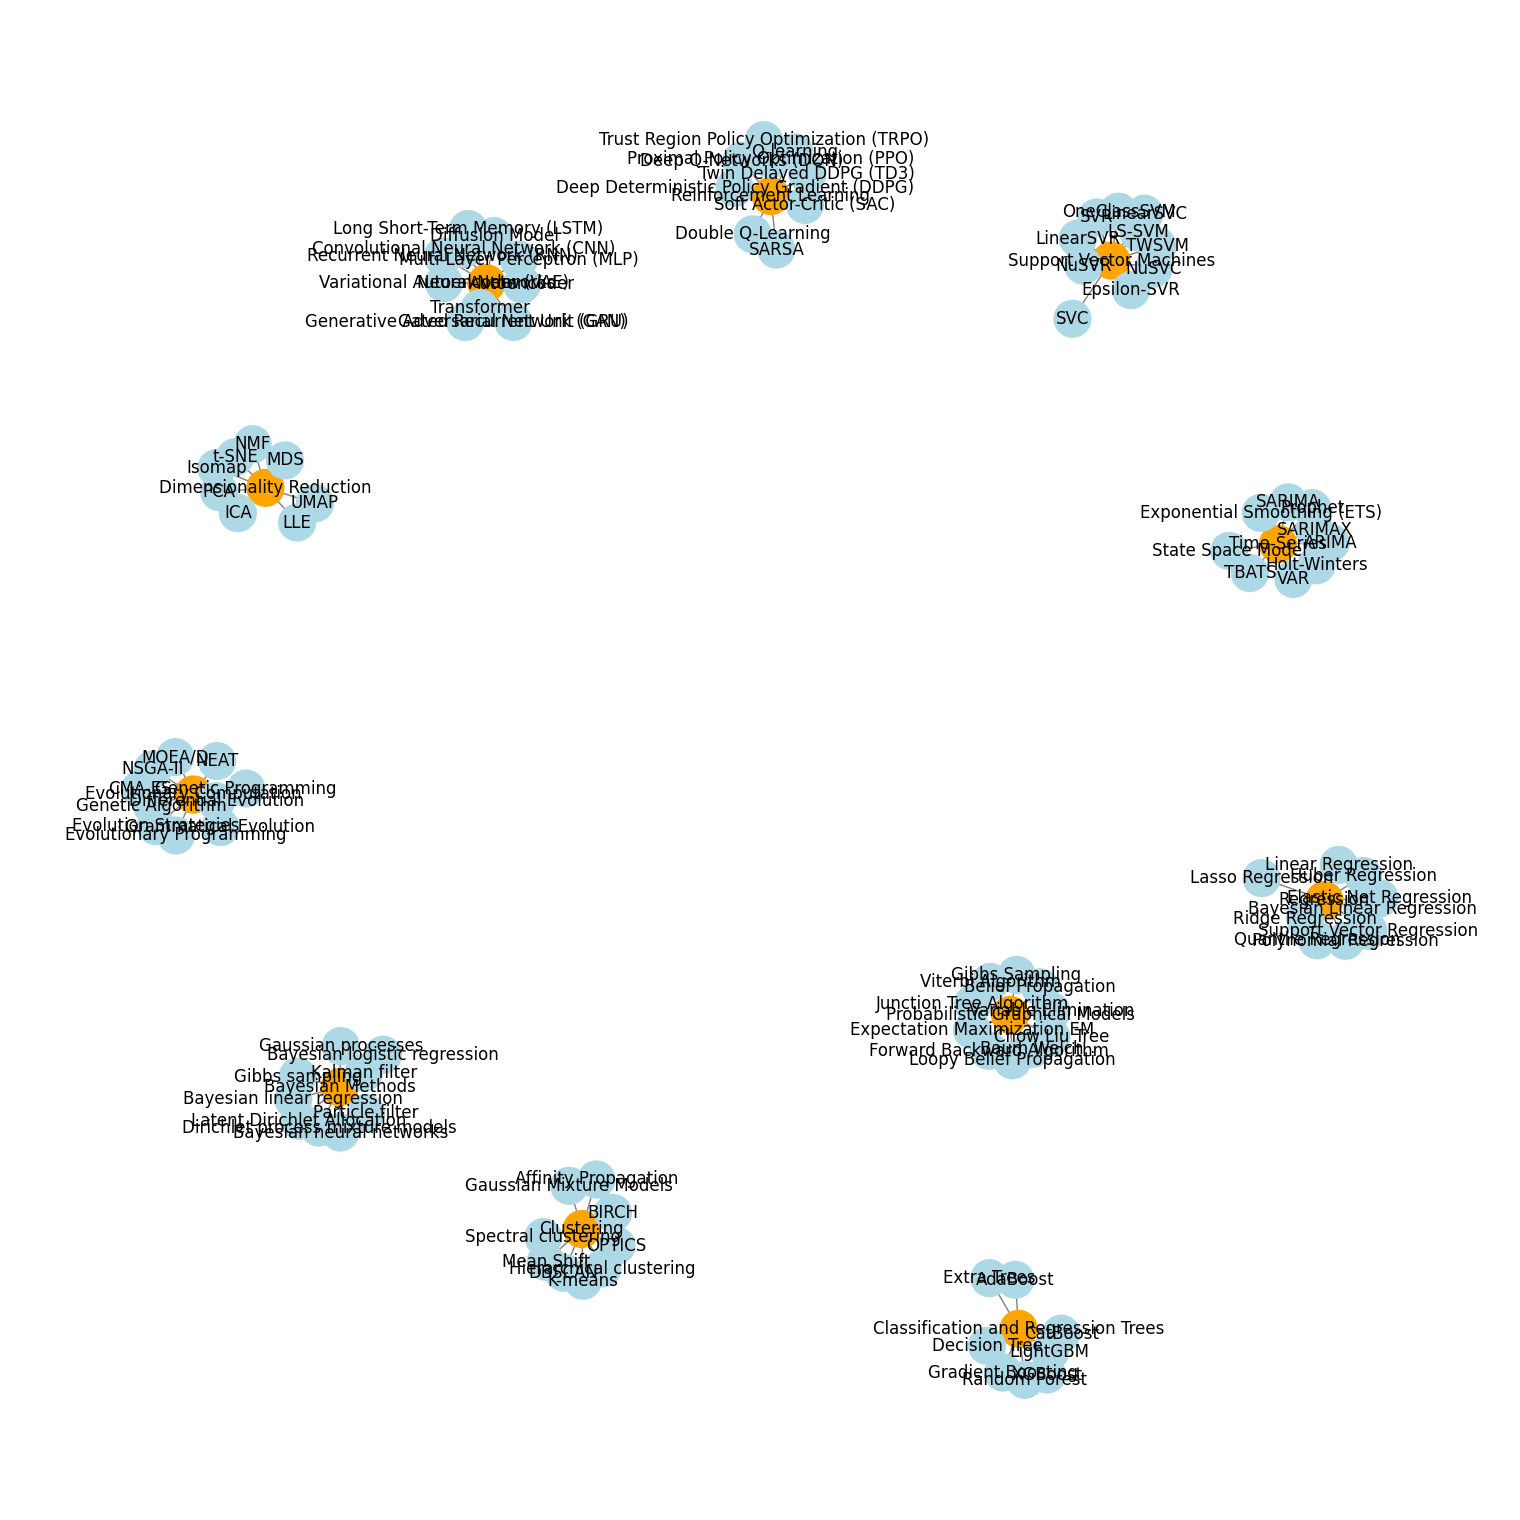

In [75]:
import matplotlib.pyplot as plt


colors = []

for node, data in graph.nodes(data=True):
    if data.get('type') == 'AIML Model Family':
        colors.append('orange')
    elif data.get('type') == 'AIML Model Algorithm':
        colors.append('lightblue')


plt.figure(figsize=(15, 15))
nx.draw(graph, with_labels=True, node_color=colors, edge_color='gray', node_size=700)
plt.show()

# Explainability Methods

In [76]:
prompt = """List 5-10 popular explainability methods for AIML models within the {model_family} model family.
            Example models in this family include {models}.
            Also provide a sinlge line description of each model explainability technique.
            Provide the results as a list of json objects with 'name' and 'description' as keys. Do not number them.
            Return only the list of json objects and no other text. Do not use any special characters. Use pure json format directly parsable by python json library."""

## Getting Information

In [17]:
from ddgs import DDGS
from bs4 import BeautifulSoup
import requests

# Searching
search_results = DDGS().text("Perceptron Python Library Documentation", max_results=5)
links = [result['href'] for result in search_results]
links
print(links)

# Fetching and parsing
response = requests.get(links[0])
soup = BeautifulSoup(response.content, 'html.parser')
content = soup.get_text(separator="\n", strip=True)

info_prompt = PromptTemplate.from_template("""From the following context, extract information about the AIML algorithm '{algorithm}'.
                                           Look for the python library name the algorithm belongs to and the class name used in that library.
                                           If no such information is found, return 'No information found'.
                                           If information is available return only the json response and no text before or after the json.
                                           Here is the context: {content}
                                           Provide the output as a dictionary in the following json format:
                                           {{'library': <library_name>, 'class': <class_name>}}
                                           Return only the json response and no other text or special characters.""")

info_chain = info_prompt | llm_json | StrOutputParser()
info_chain.invoke({'algorithm': 'Perceptron', 'content': content})

['https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html', 'https://www.geeksforgeeks.org/machine-learning/sklearn-perceptron/', 'https://pypi.org/project/Python-Perceptron/', 'https://python.plainenglish.io/building-a-perceptron-from-scratch-a-step-by-step-guide-with-python-6b8722807b2e', 'https://sharpsight.ai/blog/python-perceptron-from-scratch/']


'{\n    "library": "scikit-learn",\n    "class": "Perceptron"\n}'

In [18]:
desc_prompt = PromptTemplate.from_template("""Provide a short description on the AIML algorithm '{algorithm}'.
                                             Return only the description text and no other text.""")
description_chain = desc_prompt | llm | StrOutputParser()
# description_chain.invoke({'algorithm': 'Linear Regression'})

In [19]:
algos = {}

for fam, algs in models.items():
    for alg in algs:
        if algos.get(alg) is None:
            desc = description_chain.invoke({'algorithm': alg})
            algos[alg]['desc'] = desc
            # graph.add_node(alg, type='AIML Model Algorithm', description=desc)

KeyError: 'Linear Regression'

In [ ]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(20, 20))
# nx.draw(graph, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700)
# plt.show()